# Block F: Post-Processing and Alert Evaluation

This notebook performs alerting on top of the 3-class Random Forest model and evaluates alert behavior on a grouped holdout split (record-level split, no train/test record overlap).

Method updates in this version:
- Rebuild NICE-style 3-class pseudo-ground-truth labels from the feature matrix
- Reconstruct Block E split policy using GroupShuffleSplit
- Use explicit alert policy thresholds with clear semantics
- Smooth a single risk-state stream with causal per-record voting
- Report clinical alert metrics (false alerts/hour, transitions/hour, escalation rate)

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

PROJECT_ROOT = Path.cwd().resolve().parent  # bootstrap for src import
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import get_project_root
PROJECT_ROOT = get_project_root()

from src.nice_labels import assign_3class_labels

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"

FEATURES_CSV = OUTPUTS_DIR / "feature_matrix.csv"
MODEL_PATH = MODELS_DIR / "rf_3class_model.joblib"
THRESHOLDS_JSON = MODELS_DIR / "rf_3class_thresholds.json"
REPORT_JSON = MODELS_DIR / "rf_3class_report.json"

ALERTS_CSV = OUTPUTS_DIR / "blockF_real_time_alerts.csv"
ALERT_SUMMARY_JSON = MODELS_DIR / "blockF_alert_summary.json"
ALERT_VIZ = MODELS_DIR / "blockF_alert_timeline.png"

RANDOM_STATE = 42
TEST_SIZE = 0.30
VOTING_WINDOW = 3

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Thresholds exists: {THRESHOLDS_JSON.exists()}")
print(f"Report exists: {REPORT_JSON.exists()}")


PROJECT_ROOT: /home/naem-haq/Software-Engineering/CTG
Model exists: True
Thresholds exists: True
Report exists: True


In [2]:
pipeline = joblib.load(MODEL_PATH)
with open(THRESHOLDS_JSON, 'r') as f:
    thresholds = json.load(f)
with open(REPORT_JSON, 'r') as f:
    report = json.load(f)

df = pd.read_csv(FEATURES_CSV)
print(f"Feature matrix: {df.shape}")

print("Rebuilding NICE 3-class pseudo-ground-truth labels...")
df['label_3class'] = assign_3class_labels(df)


Feature matrix: (29989, 49)
Rebuilding NICE 3-class pseudo-ground-truth labels...


In [3]:
label_to_int = {'Normal': 0, 'Suspicious': 1, 'Pathological': 2}
int_to_label = {v: k for k, v in label_to_int.items()}

META_COLS = {
    'record_id', 'window_idx', 'start_sample', 'end_sample',
    'start_min', 'end_min', 'fs', 'outcome_label', 'label_3class'
}

LEAKAGE_FEATURES = {
    'fhr_baseline_median', 'fhr_std', 'uc_peak_rate_per_min',
    'decel_count', 'decel_max_dur_sec', 'accel_count'
}

df_eval = df[df['label_3class'].isin(label_to_int.keys())].copy()
feature_cols = [c for c in df_eval.columns if c not in (META_COLS | LEAKAGE_FEATURES)]

X = df_eval[feature_cols].astype(float)
y = df_eval['label_3class'].map(label_to_int).astype(int)
groups = df_eval['record_id'].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]
overlap = set(groups_train.unique()).intersection(set(groups_test.unique()))
assert len(overlap) == 0, 'Leakage detected: overlap between train and test records'

df_eval = df_eval.reset_index(drop=True)
df_eval['split'] = 'train'
df_eval.loc[test_idx, 'split'] = 'test'

print(f"Train windows: {len(train_idx)} from {groups_train.nunique()} records")
print(f"Test windows:  {len(test_idx)} from {groups_test.nunique()} records")
print(f"Model features expected: {report['dataset']['num_features']} | Block F features: {len(feature_cols)}")

Train windows: 21153 from 385 records
Test windows:  8836 from 165 records
Model features expected: 35 | Block F features: 35


In [4]:
X_test = X.iloc[test_idx].copy()
test_frame = df_eval.iloc[test_idx].copy()

probs = pipeline.predict_proba(X_test)
class_order = [int(c) for c in pipeline.classes_]
prob_cols = [f"prob_{int_to_label[c].lower()}" for c in class_order]
probs_df = pd.DataFrame(probs, columns=prob_cols, index=test_frame.index)

for col in ['prob_normal', 'prob_suspicious', 'prob_pathological']:
    if col not in probs_df.columns:
        probs_df[col] = 0.0

test_frame = test_frame.join(probs_df[['prob_normal', 'prob_suspicious', 'prob_pathological']])
test_frame['true_label'] = test_frame['label_3class'].map(label_to_int).astype(int)

threshold_pathological = float(thresholds.get('high_sensitivity_pathological', thresholds.get('default', 0.5)))
threshold_suspicious = 0.50

def classify_alert_state(row):
    if row['prob_pathological'] >= threshold_pathological:
        return 'Pathological'
    if row['prob_suspicious'] >= threshold_suspicious:
        return 'Suspicious'
    scores = [row['prob_normal'], row['prob_suspicious'], row['prob_pathological']]
    return int_to_label[int(np.argmax(scores))]

test_frame = test_frame.sort_values(['record_id', 'window_idx']).reset_index(drop=True)
test_frame['alert_raw_final'] = test_frame.apply(classify_alert_state, axis=1)

print('Alert threshold policy:')
print(f"  Pathological threshold (applies to P(Pathological), from rf_3class_thresholds.json): {threshold_pathological:.3f}")
print(f"  Suspicious threshold (explicit Block F policy):                                {threshold_suspicious:.3f}")

Alert threshold policy:
  Pathological threshold (applies to P(Pathological), from rf_3class_thresholds.json): 0.750
  Suspicious threshold (explicit Block F policy):                                0.500


In [5]:
severity = {'Normal': 0, 'Suspicious': 1, 'Pathological': 2}

def causal_majority_vote(series, window_size=3):
    values = series.tolist()
    out = []
    for i in range(len(values)):
        hist = values[max(0, i - window_size + 1): i + 1]
        counts = pd.Series(hist).value_counts()
        max_count = counts.max()
        winners = counts[counts == max_count].index.tolist()
        winner = max(winners, key=lambda x: severity[x])
        out.append(winner)
    return pd.Series(out, index=series.index)

test_frame['alert_final'] = (
    test_frame.groupby('record_id', sort=False)['alert_raw_final']
    .transform(lambda s: causal_majority_vote(s, window_size=VOTING_WINDOW))
)

test_frame['pred_raw'] = test_frame['alert_raw_final'].map(label_to_int).astype(int)
test_frame['pred_smooth'] = test_frame['alert_final'].map(label_to_int).astype(int)

print('Raw alert classification report (test only):')
print(classification_report(test_frame['true_label'], test_frame['pred_raw'], target_names=['Normal', 'Suspicious', 'Pathological']))

print('Smoothed alert classification report (test only):')
print(classification_report(test_frame['true_label'], test_frame['pred_smooth'], target_names=['Normal', 'Suspicious', 'Pathological']))

Raw alert classification report (test only):
              precision    recall  f1-score   support

      Normal       0.90      0.98      0.94      1102
  Suspicious       0.93      0.92      0.93      2400
Pathological       0.98      0.97      0.97      5334

    accuracy                           0.96      8836
   macro avg       0.94      0.95      0.95      8836
weighted avg       0.96      0.96      0.96      8836

Smoothed alert classification report (test only):
              precision    recall  f1-score   support

      Normal       0.75      0.75      0.75      1102
  Suspicious       0.79      0.77      0.78      2400
Pathological       0.91      0.92      0.92      5334

    accuracy                           0.86      8836
   macro avg       0.82      0.81      0.82      8836
weighted avg       0.86      0.86      0.86      8836



In [6]:
def monitored_hours(df_in):
    spans = df_in.groupby('record_id').apply(
        lambda g: max(0.0, float(g['end_min'].max() - g['start_min'].min()) / 60.0)
    )
    return float(spans.sum())

def transitions_per_hour(df_in, col):
    changes = 0
    for _, g in df_in.groupby('record_id'):
        g = g.sort_values('window_idx')
        vals = g[col].tolist()
        changes += sum(1 for i in range(1, len(vals)) if vals[i] != vals[i - 1])
    hours = monitored_hours(df_in)
    return float(changes / max(hours, 1e-9)), int(changes), float(hours)

total_hours = monitored_hours(test_frame)
raw_false = int(((test_frame['pred_raw'] > 0) & (test_frame['true_label'] == 0)).sum())
smooth_false = int(((test_frame['pred_smooth'] > 0) & (test_frame['true_label'] == 0)).sum())

raw_trans_per_hr, raw_transitions, hours = transitions_per_hour(test_frame, 'alert_raw_final')
smooth_trans_per_hr, smooth_transitions, _ = transitions_per_hour(test_frame, 'alert_final')

path_records = []
path_times = []
for rid, g in test_frame.groupby('record_id'):
    g = g.sort_values('window_idx')
    if (g['true_label'] == 2).any():
        path_records.append(rid)
        candidates = g[g['alert_final'] == 'Pathological']
        if len(candidates) > 0:
            t0 = float(g['start_min'].min())
            t_first = float(candidates.iloc[0]['start_min'])
            path_times.append(max(0.0, t_first - t0))

record_escalation_any = float(test_frame.groupby('record_id')['alert_final'].apply(lambda s: (s != 'Normal').any()).mean())
record_escalation_path = float(test_frame.groupby('record_id')['alert_final'].apply(lambda s: (s == 'Pathological').any()).mean())

cm_smooth = confusion_matrix(test_frame['true_label'], test_frame['pred_smooth'], labels=[0, 1, 2])

alert_summary = {
    'metadata': {
        'notebook': '06-BlockF-PostProcessing',
        'objective': 'Test-split alert evaluation for real-time CTG decision support',
        'model_source': '05-BlockE-RandomForest',
        'split_policy': 'GroupShuffleSplit(test_size=0.30, random_state=42) by record_id',
        'random_state': int(RANDOM_STATE),
        'test_size': float(TEST_SIZE),
        'train_windows': int(len(train_idx)),
        'test_windows': int(len(test_idx)),
        'train_records': int(groups_train.nunique()),
        'test_records': int(groups_test.nunique()),
        'num_features': int(len(feature_cols)),
        'model_accuracy_block_e': float(report['performance']['overall_accuracy'])
    },
    'labeling': {
        'source': 'src.nice_labels.assign_3class_labels',
        'classes': ['Normal', 'Suspicious', 'Pathological']
    },
    'threshold_policy': {
        'pathological_threshold': float(threshold_pathological),
        'pathological_threshold_source': 'rf_3class_thresholds.json.high_sensitivity_pathological',
        'threshold_tuning_source': 'validation_split_from_train_only (Block E)',
        'suspicious_threshold': float(threshold_suspicious),
        'suspicious_threshold_source': 'explicit Block F policy (0.50)',
        'notes': 'Single-state policy: Pathological if P(path) >= threshold, else Suspicious if P(susp) >= threshold, else argmax class'
    },
    'alert_statistics_test': {
        'raw_counts': test_frame['alert_raw_final'].value_counts().to_dict(),
        'smoothed_counts': test_frame['alert_final'].value_counts().to_dict(),
        'false_alerts_per_hour': {
            'raw': float(raw_false / max(total_hours, 1e-9)),
            'smoothed': float(smooth_false / max(total_hours, 1e-9))
        },
        'transitions_per_hour': {
            'raw': float(raw_trans_per_hr),
            'smoothed': float(smooth_trans_per_hr)
        },
        'record_level_escalation_rate': {
            'any_alert_non_normal': float(record_escalation_any),
            'pathological_alert': float(record_escalation_path)
        },
        'time_to_first_pathological_alert_min': {
            'evaluated_pathological_records': int(len(path_records)),
            'records_with_detected_pathological_alert': int(len(path_times)),
            'mean': float(np.mean(path_times)) if len(path_times) else None,
            'median': float(np.median(path_times)) if len(path_times) else None
        }
    },
    'performance_test': {
        'raw_accuracy': float((test_frame['true_label'] == test_frame['pred_raw']).mean()),
        'smoothed_accuracy': float((test_frame['true_label'] == test_frame['pred_smooth']).mean()),
        'smoothed_confusion_matrix_layout': '[Normal, Suspicious, Pathological]',
        'smoothed_confusion_matrix': cm_smooth.tolist()
    },
    'outputs': {
        'alerts_csv': str(ALERTS_CSV),
        'alert_summary_json': str(ALERT_SUMMARY_JSON),
        'alert_timeline_png': str(ALERT_VIZ)
    }
}

alerts_output_cols = [
    'record_id', 'window_idx', 'start_min', 'end_min',
    'label_3class', 'true_label',
    'prob_normal', 'prob_suspicious', 'prob_pathological',
    'alert_raw_final', 'alert_final'
]
alerts_output = test_frame[alerts_output_cols].copy()
alerts_output.rename(columns={
    'window_idx': 'window_index',
    'start_min': 'start_minute',
    'end_min': 'end_minute',
    'label_3class': 'true_label_str',
    'alert_raw_final': 'raw_alert_class',
    'alert_final': 'final_alert_class'
}, inplace=True)
alerts_output.to_csv(ALERTS_CSV, index=False)

with open(ALERT_SUMMARY_JSON, 'w') as f:
    json.dump(alert_summary, f, indent=2)

print(f"Saved alerts CSV: {ALERTS_CSV}")
print(f"Saved alert summary: {ALERT_SUMMARY_JSON}")
print(f"Total monitored test hours: {total_hours:.2f}")


Saved alerts CSV: /home/naem-haq/Software-Engineering/CTG/outputs/blockF_real_time_alerts.csv
Saved alert summary: /home/naem-haq/Software-Engineering/CTG/outputs/models/blockF_alert_summary.json
Total monitored test hours: 186.48


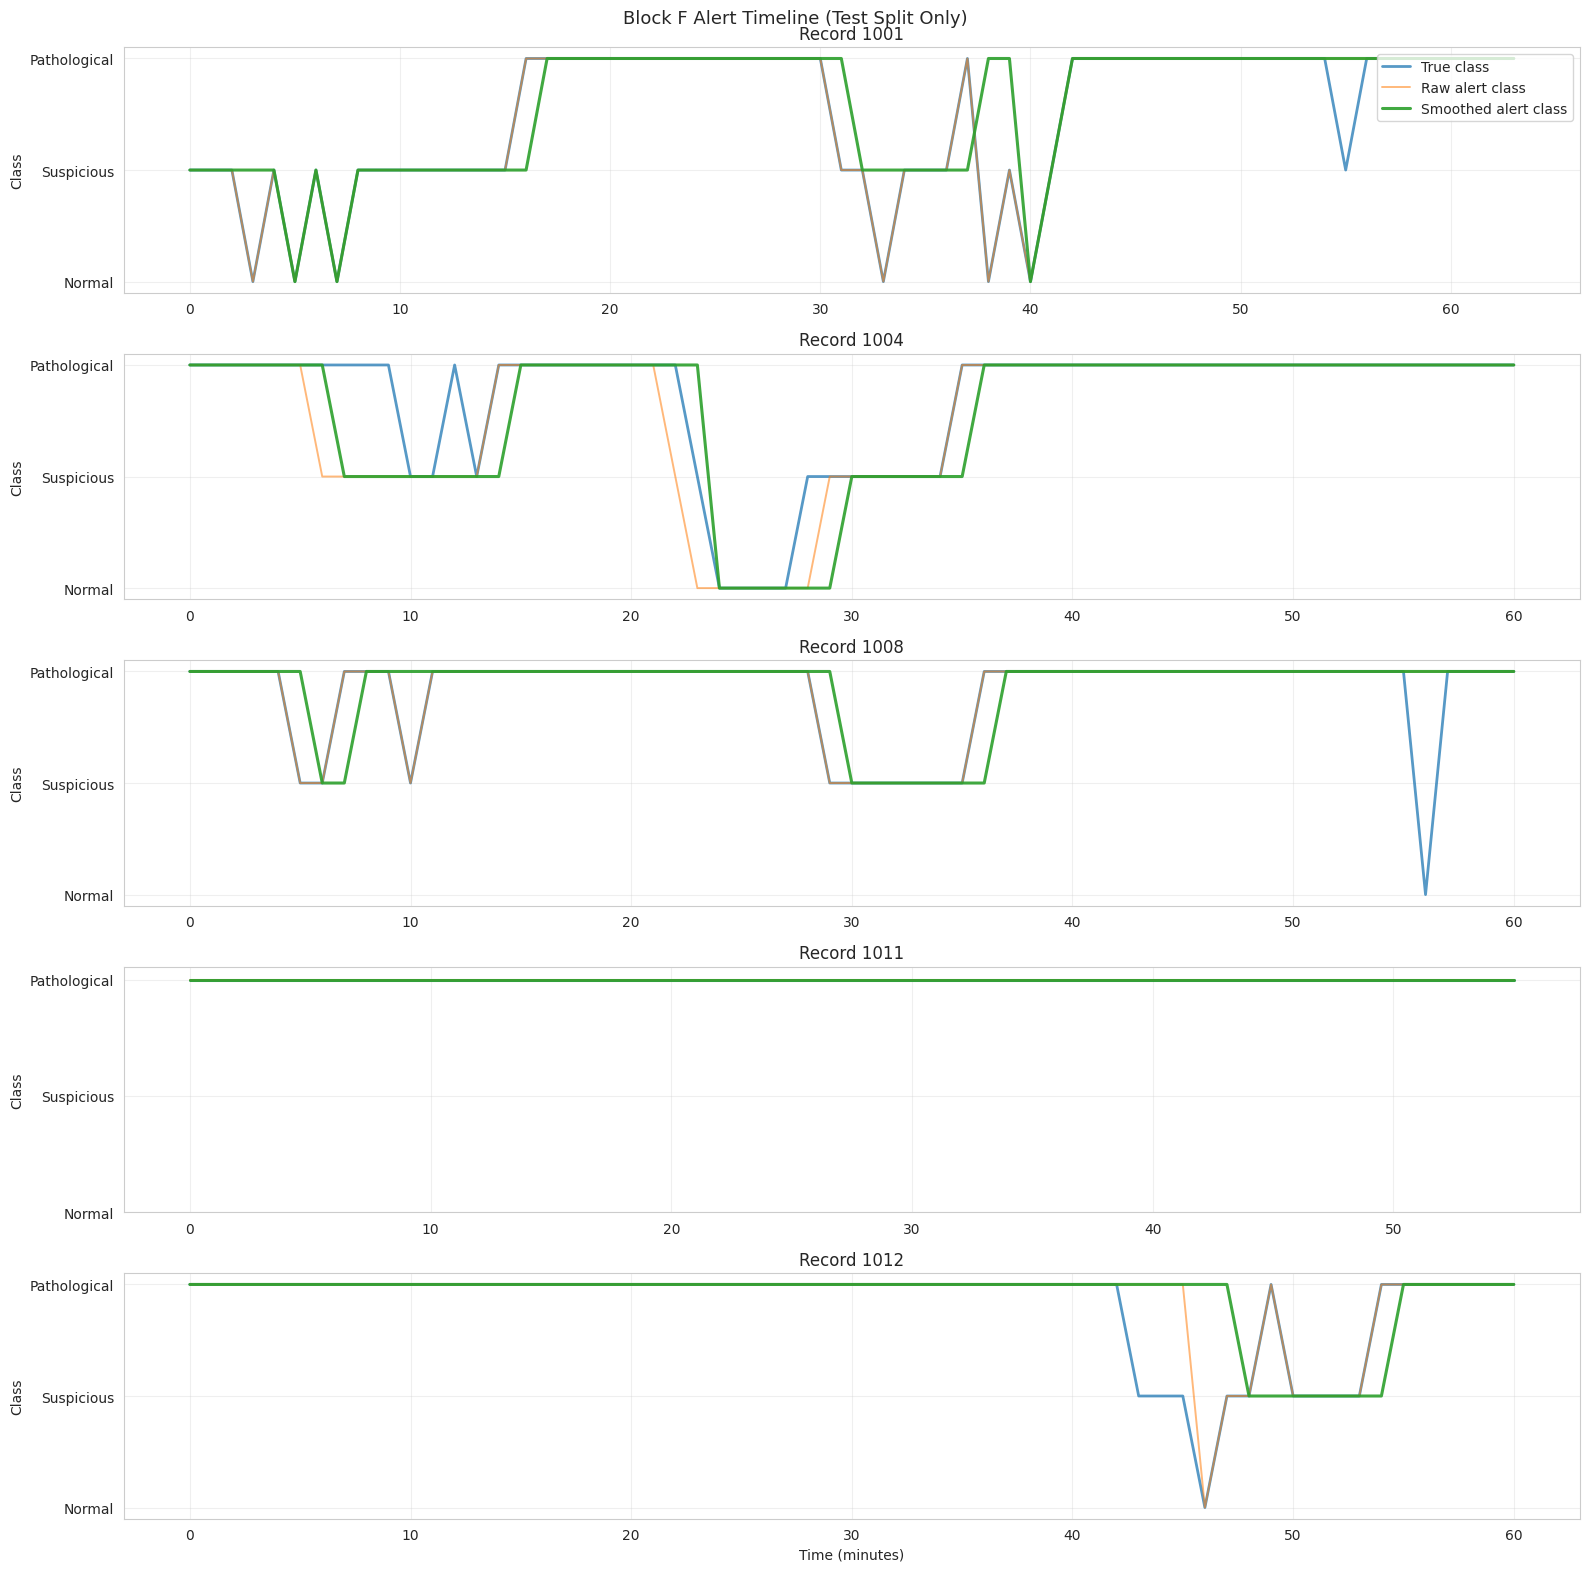

Saved timeline figure: /home/naem-haq/Software-Engineering/CTG/outputs/models/blockF_alert_timeline.png


In [7]:
sample_records = test_frame['record_id'].astype(str).unique()[:5]
fig = plt.figure(figsize=(16, 3.2 * len(sample_records)))

for idx, record_id in enumerate(sample_records):
    ax = plt.subplot(len(sample_records), 1, idx + 1)
    g = test_frame[test_frame['record_id'].astype(str) == record_id].sort_values('window_idx')
    x = g['start_min'].values
    y_true = g['true_label'].values
    y_raw = g['pred_raw'].values
    y_smooth = g['pred_smooth'].values

    ax.plot(x, y_true, linewidth=2.0, alpha=0.75, label='True class')
    ax.plot(x, y_raw, linewidth=1.4, alpha=0.55, label='Raw alert class')
    ax.plot(x, y_smooth, linewidth=2.2, alpha=0.9, label='Smoothed alert class')

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Normal', 'Suspicious', 'Pathological'])
    ax.set_ylabel('Class')
    ax.set_title(f'Record {record_id}')
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper right')

plt.xlabel('Time (minutes)')
plt.suptitle('Block F Alert Timeline (Test Split Only)', fontsize=13)
plt.tight_layout()
plt.savefig(ALERT_VIZ, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved timeline figure: {ALERT_VIZ}")

In [8]:
print('=' * 80)
print('BLOCK F SUMMARY')
print('=' * 80)
print(f"Split policy: GroupShuffleSplit(test_size={TEST_SIZE}, random_state={RANDOM_STATE}) by record_id")
print(f"Test windows: {len(test_frame)} from {test_frame['record_id'].nunique()} records")
print(f"Path threshold: {threshold_pathological:.3f} (from model threshold file)")
print(f"Susp threshold: {threshold_suspicious:.3f} (explicit Block F policy)")
print(f"Raw accuracy: {(test_frame['true_label'] == test_frame['pred_raw']).mean():.3f}")
print(f"Smoothed accuracy: {(test_frame['true_label'] == test_frame['pred_smooth']).mean():.3f}")
print(f"False alerts/hour (raw -> smooth): {raw_false / max(total_hours, 1e-9):.2f} -> {smooth_false / max(total_hours, 1e-9):.2f}")
print(f"Transitions/hour (raw -> smooth): {raw_trans_per_hr:.2f} -> {smooth_trans_per_hr:.2f}")
print('=' * 80)

BLOCK F SUMMARY
Split policy: GroupShuffleSplit(test_size=0.3, random_state=42) by record_id
Test windows: 8836 from 165 records
Path threshold: 0.750 (from model threshold file)
Susp threshold: 0.500 (explicit Block F policy)
Raw accuracy: 0.956
Smoothed accuracy: 0.859
False alerts/hour (raw -> smooth): 0.14 -> 1.47
Transitions/hour (raw -> smooth): 8.22 -> 4.74
